[*********************100%***********************]  1 of 1 completed


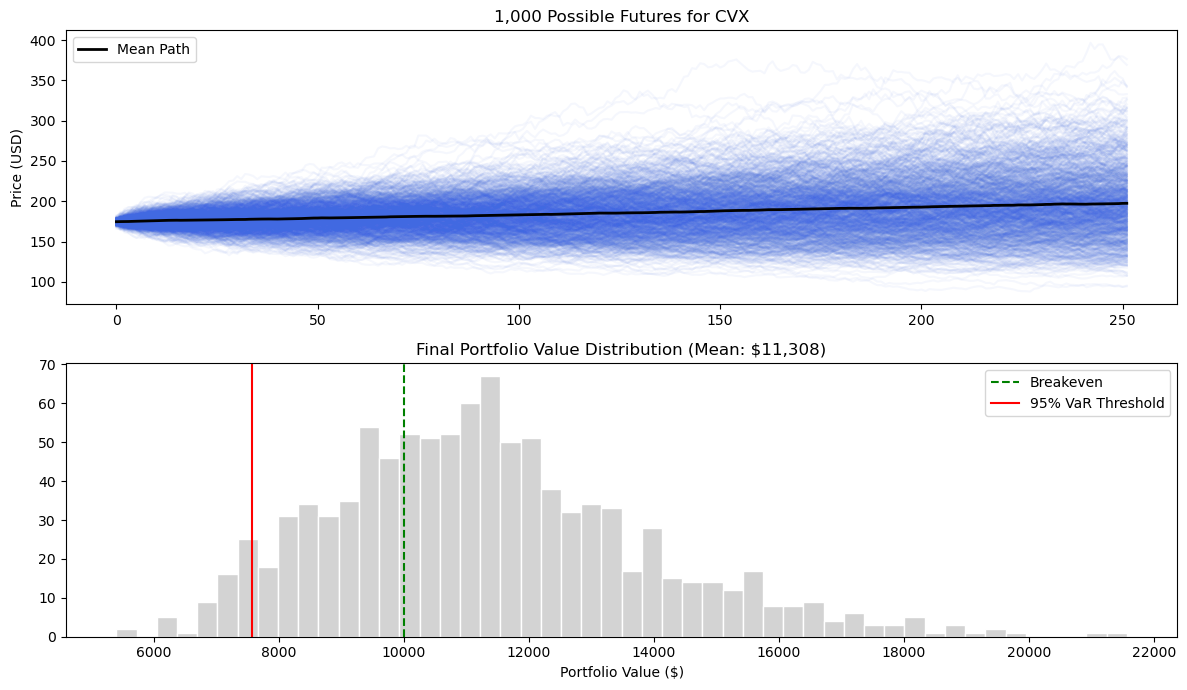

--- Quant Report: CVX ---
Current Investment:   $10,000.00
Expected Value (1yr): $11,307.74
Probability of Profit: 68.40%
95% Confidence Value: $7,579.28


In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def run_full_monte_carlo(ticker="CVX", initial_investment=10000, num_sims=1000):
    # 1. Download 2 years of data for stable stats
    data = yf.download(ticker, period="2y")['Close']
    if isinstance(data, pd.DataFrame):
        data = data[ticker]
    
    # 2. Calculate Log Returns (Better for statistical modeling)
    log_returns = np.log(1 + data.pct_change().dropna())
    mu = log_returns.mean()
    sigma = log_returns.std()
    
    # 3. Simulation Parameters
    forecast_days = 252  # 1 trading year
    last_price = data.iloc[-1]
    
    # 4. Vectorized Simulation (No for-loops!)
    # Generate a matrix of (forecast_days x num_sims) random normal values
    z = np.random.standard_normal((forecast_days, num_sims))
    
    # Apply Geometric Brownian Motion formula
    daily_growth = np.exp((mu - 0.5 * sigma**2) + sigma * z)
    
    # Calculate price paths across the entire matrix at once
    # We use np.vander-like logic with cumprod along the rows (axis=0)
    price_paths = last_price * daily_growth.cumprod(axis=0)
    
    # Convert to DataFrame for easier plotting
    sim_df = pd.DataFrame(price_paths)
    
    # 5. Calculate Metrics
    final_prices = sim_df.iloc[-1]
    final_portfolio_values = (final_prices / last_price) * initial_investment
    
    mean_final = final_portfolio_values.mean()
    prob_of_profit = (final_portfolio_values > initial_investment).sum() / num_sims
    worst_5_percent = np.percentile(final_portfolio_values, 5)

    # 6. Visualization
    plt.figure(figsize=(12, 7))
    
    # Subplot 1: Price Paths
    plt.subplot(2, 1, 1)
    plt.plot(sim_df, color='royalblue', alpha=0.05) # Faint lines for paths
    plt.plot(sim_df.mean(axis=1), color='black', linewidth=2, label="Mean Path")
    plt.title(f"1,000 Possible Futures for {ticker}")
    plt.ylabel("Price (USD)")
    plt.legend()
    
    # Subplot 2: Histogram of Final Portfolio Values
    plt.subplot(2, 1, 2)
    plt.hist(final_portfolio_values, bins=50, color='lightgray', edgecolor='white')
    plt.axvline(initial_investment, color='green', linestyle='--', label="Breakeven")
    plt.axvline(worst_5_percent, color='red', label="95% VaR Threshold")
    plt.title(f"Final Portfolio Value Distribution (Mean: ${mean_final:,.0f})")
    plt.xlabel("Portfolio Value ($)")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    print(f"--- Quant Report: {ticker} ---")
    print(f"Current Investment:   ${initial_investment:,.2f}")
    print(f"Expected Value (1yr): ${mean_final:,.2f}")
    print(f"Probability of Profit: {prob_of_profit:.2%}")
    print(f"95% Confidence Value: ${worst_5_percent:,.2f}")

# Execute
run_full_monte_carlo("CVX")